# Catechism of the Catholic Church: Graph Exploration

This notebook explores the Catechism data added in Phase 4, with emphasis on discovering **implicit biblical connections** created by CCC citations.

**Key Insight**: When a CCC paragraph cites multiple Bible verses, it creates an implicit connection between those verses - even if they aren't directly cross-referenced in TSK or Haydock.

**Contents**:
1. CCC Data Overview
2. Most-Cited Verses in the Catechism
3. Implicit Bible Connections Through CCC
4. CCC as Testament Bridge (OT↔NT)
5. External Document Analysis

## Imports

Load the database connection and visualization libraries.

In [1]:
import sys
sys.path.insert(0, '../..')

from src.db.connection import get_connection

import pandas as pd
import matplotlib.pyplot as plt
from pyvis.network import Network

## Configuration

Establish connection to Neo4j and define color schemes.

In [2]:
conn = get_connection()
conn.connect()
conn.verify()
print("Connected to Neo4j!")

Connected to Neo4j!


In [3]:
# Color scheme by book category (matching other notebooks)
BOOK_COLORS = {
    # Pentateuch (Torah) - Blue
    "GEN": "#3498db", "EXO": "#3498db", "LEV": "#3498db", "NUM": "#3498db", "DEU": "#3498db",
    # Historical Books - Green
    "JOS": "#27ae60", "JDG": "#27ae60", "RUT": "#27ae60", "1SA": "#27ae60", "2SA": "#27ae60",
    "1KI": "#27ae60", "2KI": "#27ae60", "1CH": "#27ae60", "2CH": "#27ae60", "EZR": "#27ae60",
    "NEH": "#27ae60", "EST": "#27ae60",
    # Deuterocanonical - Teal
    "TOB": "#16a085", "JDT": "#16a085", "1MA": "#16a085", "2MA": "#16a085",
    "WIS": "#16a085", "SIR": "#16a085", "BAR": "#16a085",
    # Wisdom/Poetry - Gold
    "JOB": "#f39c12", "PSA": "#f39c12", "PRO": "#f39c12", "ECC": "#f39c12", "SNG": "#f39c12",
    # Major Prophets - Red
    "ISA": "#e74c3c", "JER": "#e74c3c", "LAM": "#e74c3c", "EZK": "#e74c3c", "DAN": "#e74c3c",
    # Minor Prophets - Orange
    "HOS": "#e67e22", "JOL": "#e67e22", "AMO": "#e67e22", "OBA": "#e67e22", "JON": "#e67e22",
    "MIC": "#e67e22", "NAM": "#e67e22", "HAB": "#e67e22", "ZEP": "#e67e22", "HAG": "#e67e22",
    "ZEC": "#e67e22", "MAL": "#e67e22",
    # Gospels - Purple
    "MAT": "#9b59b6", "MRK": "#9b59b6", "LUK": "#9b59b6", "JHN": "#9b59b6",
    # Acts - Light Purple
    "ACT": "#8e44ad",
    # Pauline Epistles - Pink
    "ROM": "#e91e63", "1CO": "#e91e63", "2CO": "#e91e63", "GAL": "#e91e63", "EPH": "#e91e63",
    "PHP": "#e91e63", "COL": "#e91e63", "1TH": "#e91e63", "2TH": "#e91e63", "1TI": "#e91e63",
    "2TI": "#e91e63", "TIT": "#e91e63", "PHM": "#e91e63",
    # General Epistles - Cyan
    "HEB": "#00bcd4", "JAS": "#00bcd4", "1PE": "#00bcd4", "2PE": "#00bcd4",
    "1JN": "#00bcd4", "2JN": "#00bcd4", "3JN": "#00bcd4", "JUD": "#00bcd4",
    # Revelation - Dark Red
    "REV": "#c0392b",
}

# CCC nodes get their own color
CCC_COLOR = "#1abc9c"  # Teal

# OT books list (for testament detection)
OT_BOOKS = [
    # Pentateuch
    "GEN", "EXO", "LEV", "NUM", "DEU",
    # Historical
    "JOS", "JDG", "RUT", "1SA", "2SA", "1KI", "2KI", "1CH", "2CH", "EZR", "NEH", "EST",
    # Deuterocanonical
    "TOB", "JDT", "1MA", "2MA", "WIS", "SIR", "BAR",
    # Wisdom/Poetry
    "JOB", "PSA", "PRO", "ECC", "SNG",
    # Prophets
    "ISA", "JER", "LAM", "EZK", "DAN",
    "HOS", "JOL", "AMO", "OBA", "JON", "MIC", "NAM", "HAB", "ZEP", "HAG", "ZEC", "MAL"
]

def get_book_color(book_id):
    """Get color for a book, with fallback."""
    return BOOK_COLORS.get(book_id, "#95a5a6")

def is_ot_book(book_id):
    """Check if a book is in the Old Testament."""
    return book_id in OT_BOOKS

## 1. CCC Data Overview

Get a high-level view of the Catechism data in the graph.

In [4]:
with conn.session() as session:
    # CCC paragraph count
    result = session.run("MATCH (c:CatechismParagraph) RETURN count(c) AS count")
    ccc_count = result.single()["count"]
    print(f"CCC Paragraphs: {ccc_count:,}")
    
    # CCC internal cross-references
    result = session.run("""
        MATCH (:CatechismParagraph)-[r:CROSS_REFERENCES]->(:CatechismParagraph)
        RETURN count(r) AS count
    """)
    internal_refs = result.single()["count"]
    print(f"CCC Internal Cross-References: {internal_refs:,}")
    
    # CCC → Scripture citations
    result = session.run("""
        MATCH (:CatechismParagraph)-[r:CITES]->(:Verse)
        RETURN count(r) AS count
    """)
    scripture_cites = result.single()["count"]
    print(f"CCC → Scripture Citations: {scripture_cites:,}")
    
    # Unique verses cited
    result = session.run("""
        MATCH (:CatechismParagraph)-[:CITES]->(v:Verse)
        RETURN count(DISTINCT v) AS count
    """)
    unique_verses = result.single()["count"]
    print(f"Unique Verses Cited: {unique_verses:,}")
    
    # External documents
    result = session.run("MATCH (d:ExternalDocument) RETURN count(d) AS count")
    ext_docs = result.single()["count"]
    print(f"External Documents: {ext_docs:,}")
    
    # CCC → External document citations
    result = session.run("""
        MATCH (:CatechismParagraph)-[r:CITES]->(:ExternalDocument)
        RETURN count(r) AS count
    """)
    ext_cites = result.single()["count"]
    print(f"CCC → External Doc Citations: {ext_cites:,}")

CCC Paragraphs: 2,865
CCC Internal Cross-References: 3,713
CCC → Scripture Citations: 1,998
Unique Verses Cited: 1,540
External Documents: 390
CCC → External Doc Citations: 527


### Citations per paragraph distribution

How many Scripture citations does a typical CCC paragraph have?

Received notification from DBMS server: <GqlStatusObject gql_status='01G11', status_description='warn: null value eliminated in set function', position=None, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_status_parameters': {}, '_severity': 'WARNING', 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (c:CatechismParagraph)\n        OPTIONAL MATCH (c)-[r:CITES]->(:Verse)\n        WITH c.paragraph AS para, count(r) AS citations\n        RETURN citations, count(*) AS paragraphs\n        ORDER BY citations\n    '


Paragraphs with Scripture citations: 411 (14.3%)
Paragraphs without citations: 2,454


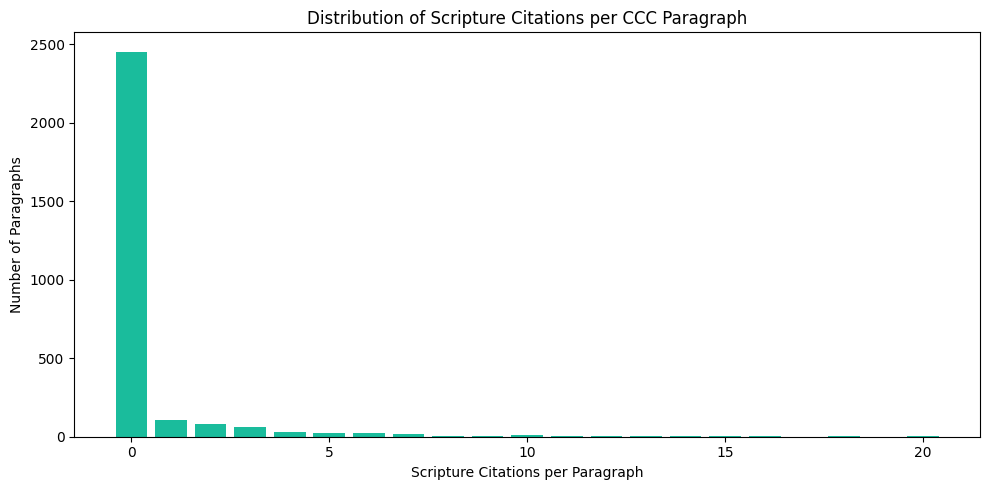

In [5]:
with conn.session() as session:
    result = session.run("""
        MATCH (c:CatechismParagraph)
        OPTIONAL MATCH (c)-[r:CITES]->(:Verse)
        WITH c.paragraph AS para, count(r) AS citations
        RETURN citations, count(*) AS paragraphs
        ORDER BY citations
    """)
    
    data = [(r["citations"], r["paragraphs"]) for r in result]
    citations, counts = zip(*data)
    
    # Summary stats
    total_paras = sum(counts)
    paras_with_citations = sum(c for cit, c in data if cit > 0)
    print(f"Paragraphs with Scripture citations: {paras_with_citations:,} ({100*paras_with_citations/total_paras:.1f}%)")
    print(f"Paragraphs without citations: {total_paras - paras_with_citations:,}")

# Plot distribution (capped at 20 for readability)
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = [(c, n) for c, n in data if c <= 20]
x = [d[0] for d in plot_data]
y = [d[1] for d in plot_data]
ax.bar(x, y, color='#1abc9c')
ax.set_xlabel('Scripture Citations per Paragraph')
ax.set_ylabel('Number of Paragraphs')
ax.set_title('Distribution of Scripture Citations per CCC Paragraph')
plt.tight_layout()
plt.show()

## 2. Most-Cited Verses in the Catechism

Which verses does the Church cite most frequently in the Catechism?

In [6]:
with conn.session() as session:
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[r:CITES]->(v:Verse)
        WITH v, count(r) AS citations, collect(ccc.paragraph) AS citing_paragraphs
        ORDER BY citations DESC
        LIMIT 20
        RETURN v.id AS verse_id, v.text AS text, citations, citing_paragraphs
    """)
    
    print("Top 20 Most-Cited Verses in the Catechism:\n")
    ccc_top_verses = []
    for r in result:
        verse_id = r["verse_id"]
        citations = r["citations"]
        text = r["text"][:80] + "..." if len(r["text"]) > 80 else r["text"]
        ccc_top_verses.append((verse_id, citations))
        print(f"{verse_id} ({citations} citations):")
        print(f"  {text}\n")

Top 20 Most-Cited Verses in the Catechism:

MAT-28-19 (11 citations):
  Therefore, go forth and teach all nations, baptizing them in the name of the Fat...

MAT-28-20 (7 citations):
  teaching them to observe all that I have ever commanded you. And behold, I am wi...

GEN-1-28 (6 citations):
  And God blessed them, and he said, “Increase and multiply, and fill the earth, a...

ROM-5-20 (6 citations):
  Now the law entered in such a way that offenses would abound. But where offenses...

GEN-3-5 (6 citations):
  For God knows that, on whatever day you will eat from it, your eyes will be open...

JHN-15-5 (6 citations):
  I am the vine; you are the branches. Whoever abides in me, and I in him, bears m...

GEN-3-9 (5 citations):
  And the Lord God called Adam and said to him: “Where are you?”

GEN-2-24 (5 citations):
  For this reason, a man shall leave behind his father and mother, and he shall cl...

GEN-1-27 (5 citations):
  And God created man to his own image; to the image of God he c

### Compare to TSK/Haydock Most-Referenced Verses

Are the verses the Church cites most the same as those most cross-referenced in traditional sources?

In [7]:
with conn.session() as session:
    # Get most-referenced verses in TSK/Haydock
    result = session.run("""
        MATCH (v:Verse)<-[r:CROSS_REFERENCES]-()
        WITH v, count(r) AS refs
        ORDER BY refs DESC
        LIMIT 20
        RETURN v.id AS verse_id, refs
    """)
    tsk_top = {r["verse_id"]: r["refs"] for r in result}
    
    # Compare
    ccc_verse_ids = set(v[0] for v in ccc_top_verses)
    tsk_verse_ids = set(tsk_top.keys())
    
    overlap = ccc_verse_ids & tsk_verse_ids
    ccc_unique = ccc_verse_ids - tsk_verse_ids
    tsk_unique = tsk_verse_ids - ccc_verse_ids
    
    print(f"Overlap in top 20: {len(overlap)} verses")
    print(f"In both: {sorted(overlap)}\n")
    
    print(f"Unique to CCC top 20 (Church emphasis): {len(ccc_unique)} verses")
    for v in sorted(ccc_unique):
        print(f"  {v}")
    
    print(f"\nUnique to TSK/Haydock top 20: {len(tsk_unique)} verses")
    for v in sorted(tsk_unique):
        print(f"  {v}")

Overlap in top 20: 1 verses
In both: ['MAT-28-20']

Unique to CCC top 20 (Church emphasis): 19 verses
  2PE-1-4
  ACT-2-36
  EPH-1-4
  GEN-1-1
  GEN-1-27
  GEN-1-28
  GEN-2-24
  GEN-3-10
  GEN-3-5
  GEN-3-8
  GEN-3-9
  JHN-15-5
  LUK-1-35
  LUK-1-37
  MAT-19-6
  MAT-28-19
  ROM-1-19
  ROM-5-19
  ROM-5-20

Unique to TSK/Haydock top 20: 19 verses
  1PE-2-9
  2CO-4-6
  2CO-5-21
  2PE-2-3
  2TH-2-10
  ACT-26-18
  EPH-3-8
  GAL-5-22
  ISA-55-7
  ISA-9-6
  ISA-9-7
  JER-23-5
  JER-23-6
  PSA-2-6
  REV-11-15
  REV-19-20
  REV-5-9
  TIT-2-14
  TIT-3-5


## 3. Implicit Bible Connections Through CCC

This is the key insight: when a CCC paragraph cites multiple verses, those verses become **implicitly connected** through the Catechism's theological interpretation.

We'll find verse pairs that:
1. Are both cited by the same CCC paragraph(s)
2. Have NO direct CROSS_REFERENCES edge in TSK/Haydock

These are **new connections** the Catechism reveals!

### Helper: Identifying true cross-references

When CCC cites "Mt 28:19-20", it expands to individual verses. But MAT-28-19 and MAT-28-20 aren't cross-referencing each other - they're part of the same passage.

**True cross-references** are when CCC connects verses from:
- Different books (e.g., Genesis and John)
- Different chapters
- Non-consecutive verses (more than 3 verses apart in the same chapter)

The queries below filter out same-passage pairs to find **genuine new connections**.

In [8]:
with conn.session() as session:
    # Total cross-passage verse pairs connected through CCC
    result = session.run("""
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        RETURN count(DISTINCT [v1.id, v2.id]) AS total_pairs
    """)
    total_pairs = result.single()["total_pairs"]
    print(f"Total cross-passage verse pairs connected through CCC: {total_pairs:,}")
    
    # Pairs that already have CROSS_REFERENCES
    result = session.run("""
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id 
          AND (v1)-[:CROSS_REFERENCES]-(v2)
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        RETURN count(DISTINCT [v1.id, v2.id]) AS existing_pairs
    """)
    existing_pairs = result.single()["existing_pairs"]
    print(f"Pairs already in TSK/Haydock: {existing_pairs:,}")
    
    # NEW pairs only through CCC
    result = session.run("""
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id 
          AND NOT (v1)-[:CROSS_REFERENCES]-(v2)
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        RETURN count(DISTINCT [v1.id, v2.id]) AS new_pairs
    """)
    new_pairs = result.single()["new_pairs"]
    print(f"\nNEW verse connections through CCC: {new_pairs:,}")
    if total_pairs > 0:
        print(f"  ({100*new_pairs/total_pairs:.1f}% of CCC-connected pairs are new!)")

Total cross-passage verse pairs connected through CCC: 8,657
Pairs already in TSK/Haydock: 813

NEW verse connections through CCC: 7,844
  (90.6% of CCC-connected pairs are new!)


### Top new verse connections

Which verse pairs are most strongly connected through CCC but have no direct cross-reference?

In [9]:
with conn.session() as session:
    result = session.run("""
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id 
          AND NOT (v1)-[:CROSS_REFERENCES]-(v2)
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        WITH v1, v2, count(DISTINCT ccc) AS shared_citations, 
             collect(DISTINCT ccc.paragraph) AS citing_paragraphs
        ORDER BY shared_citations DESC
        LIMIT 30
        RETURN v1.id AS verse1, v2.id AS verse2, shared_citations, citing_paragraphs,
               v1.text AS text1, v2.text AS text2
    """)
    
    print("Top 30 NEW Verse Connections Through CCC:\n")
    new_connections = []
    for r in result:
        v1, v2 = r["verse1"], r["verse2"]
        shared = r["shared_citations"]
        paras = r["citing_paragraphs"][:5]  # Show first 5
        new_connections.append((v1, v2, shared, r["citing_paragraphs"]))
        print(f"{v1} ↔ {v2} (shared by {shared} CCC paragraphs)")
        print(f"  CCC refs: {paras}{'...' if len(r['citing_paragraphs']) > 5 else ''}")

Top 30 NEW Verse Connections Through CCC:

HOS-11-1 ↔ ISA-49-14 (shared by 2 CCC paragraphs)
  CCC refs: [219, 370]
LUK-1-27 ↔ ROM-4-18 (shared by 2 CCC paragraphs)
  CCC refs: [706, 723]
WIS-13-2 ↔ WIS-13-6 (shared by 2 CCC paragraphs)
  CCC refs: [32, 216]
WIS-7-17 ↔ WIS-7-21 (shared by 2 CCC paragraphs)
  CCC refs: [216, 283]
GEN-2-18 ↔ GEN-2-23 (shared by 2 CCC paragraphs)
  CCC refs: [371, 1605]
ROM-1-21 ↔ ROM-1-25 (shared by 2 CCC paragraphs)
  CCC refs: [401, 844]
WIS-13-4 ↔ WIS-13-8 (shared by 2 CCC paragraphs)
  CCC refs: [32, 216]
WIS-13-1 ↔ WIS-13-8 (shared by 2 CCC paragraphs)
  CCC refs: [32, 216]
WIS-13-1 ↔ WIS-13-6 (shared by 2 CCC paragraphs)
  CCC refs: [32, 216]
ROM-1-19 ↔ WIS-13-1 (shared by 2 CCC paragraphs)
  CCC refs: [32, 1147]
JHN-14-17 ↔ JHN-14-26 (shared by 2 CCC paragraphs)
  CCC refs: [243, 729]
WIS-13-1 ↔ WIS-13-7 (shared by 2 CCC paragraphs)
  CCC refs: [32, 216]
GEN-3-10 ↔ GEN-3-6 (shared by 2 CCC paragraphs)
  CCC refs: [397, 399]
ROM-1-28 ↔ ROM-1-32 (sh

### Deep dive: Examine a strong new connection

Let's look at a specific verse pair connected through CCC and see what the Catechism teaches about their relationship.

In [10]:
# Pick the top new connection
if new_connections:
    v1, v2, shared, paras = new_connections[0]
    
    with conn.session() as session:
        # Get verse texts
        result = session.run("""
            MATCH (v:Verse) WHERE v.id IN [$v1, $v2]
            RETURN v.id AS id, v.text AS text
        """, v1=v1, v2=v2)
        verses = {r["id"]: r["text"] for r in result}
        
        print(f"=== New Connection: {v1} ↔ {v2} ===")
        print(f"\nShared by {shared} CCC paragraphs\n")
        print(f"{v1}:")
        print(f"  \"{verses.get(v1, 'N/A')}\"\n")
        print(f"{v2}:")
        print(f"  \"{verses.get(v2, 'N/A')}\"\n")
        
        # Get CCC paragraph texts (first 3)
        result = session.run("""
            MATCH (c:CatechismParagraph)
            WHERE c.paragraph IN $paras
            RETURN c.paragraph AS para, c.text AS text
            LIMIT 3
        """, paras=paras[:3])
        
        print("CCC Paragraphs connecting these verses:\n")
        for r in result:
            text = r["text"][:300] + "..." if len(r["text"]) > 300 else r["text"]
            print(f"CCC {r['para']}:")
            print(f"  {text}\n")

=== New Connection: HOS-11-1 ↔ ISA-49-14 ===

Shared by 2 CCC paragraphs

HOS-11-1:
  "Just as the morning passes, so has the king of Israel passed by. For Israel was a child and I loved him; and out of Egypt I called my son."

ISA-49-14:
  "And Zion said: “The Lord has abandoned me, and the Lord has forgotten me.”"

CCC Paragraphs connecting these verses:

CCC 219:
  God's love for Israel is compared to a father's love for his son. His love for his people is stronger than a mother's for her children. God loves his people more than a bridegroom his beloved; his love will be victorious over even the worst infidelities and will extend to his most precious gift: "Go...

CCC 370:
  In no way is God in man's image. He is neither man nor woman. God is pure spirit in which there is no place for the difference between the sexes. But the respective "perfections" of man and woman reflect something of the infinite perfection of God: those of a mother and those of a father and husband...



### Visualize new connections network

Create an interactive graph showing the top new verse connections discovered through CCC.

In [11]:
def visualize_ccc_connections(min_shared=2, limit=100):
    """Visualize verse pairs connected through CCC but not TSK/Haydock.
    
    Args:
        min_shared: Minimum shared CCC citations to include
        limit: Maximum edges to show
    """
    net = Network(
        height="700px",
        width="100%",
        bgcolor="#222222",
        font_color="white",
        notebook=True,
        cdn_resources='in_line'
    )
    net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=200)
    
    query = """
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id 
          AND NOT (v1)-[:CROSS_REFERENCES]-(v2)
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        WITH v1, v2, count(DISTINCT ccc) AS shared
        WHERE shared >= $min_shared
        RETURN v1.id AS v1_id, v1.book_id AS v1_book, v1.text AS v1_text,
               v2.id AS v2_id, v2.book_id AS v2_book, v2.text AS v2_text,
               shared
        ORDER BY shared DESC
        LIMIT $limit
    """
    
    added_nodes = set()
    
    with conn.session() as session:
        results = session.run(query, min_shared=min_shared, limit=limit)
        
        for r in results:
            # Add nodes
            for vid, book, text in [(r["v1_id"], r["v1_book"], r["v1_text"]),
                                    (r["v2_id"], r["v2_book"], r["v2_text"])]:
                if vid not in added_nodes:
                    net.add_node(
                        vid,
                        label=vid,
                        title=text[:200] if text else "",
                        color=get_book_color(book),
                        size=20
                    )
                    added_nodes.add(vid)
            
            # Add edge
            net.add_edge(
                r["v1_id"],
                r["v2_id"],
                title=f"Shared by {r['shared']} CCC paragraphs",
                width=max(1, r["shared"]),
                color="#1abc9c"  # CCC teal
            )
    
    print(f"Graph: {len(added_nodes)} verses, showing connections shared by {min_shared}+ CCC paragraphs")
    return net

In [12]:
net = visualize_ccc_connections(min_shared=2, limit=75)
net.show("ccc_new_connections.html")

Graph: 46 verses, showing connections shared by 2+ CCC paragraphs
ccc_new_connections.html


### New connections by testament combination

Are these new connections mostly within testaments or across them?

In [13]:
with conn.session() as session:
    result = session.run("""
        MATCH (v1:Verse)<-[:CITES]-(ccc:CatechismParagraph)-[:CITES]->(v2:Verse)
        WHERE v1.id < v2.id 
          AND NOT (v1)-[:CROSS_REFERENCES]-(v2)
          AND NOT (v1.book_id = v2.book_id AND v1.chapter = v2.chapter AND abs(v1.verse - v2.verse) <= 3)
        WITH v1, v2,
             CASE WHEN v1.book_id IN $ot_books THEN 'OT' ELSE 'NT' END AS t1,
             CASE WHEN v2.book_id IN $ot_books THEN 'OT' ELSE 'NT' END AS t2
        WITH CASE 
             WHEN t1 = 'OT' AND t2 = 'OT' THEN 'OT-OT'
             WHEN t1 = 'NT' AND t2 = 'NT' THEN 'NT-NT'
             ELSE 'OT-NT' END AS connection_type
        RETURN connection_type, count(*) AS count
        ORDER BY count DESC
    """, ot_books=OT_BOOKS)
    
    print("New CCC connections by testament:\n")
    total = 0
    data = []
    for r in result:
        conn_type = r["connection_type"]
        count = r["count"]
        total += count
        data.append((conn_type, count))
    
    for conn_type, count in data:
        print(f"  {conn_type}: {count:,} ({100*count/total:.1f}%)")

New CCC connections by testament:

  NT-NT: 4,204 (52.4%)
  OT-NT: 2,114 (26.4%)
  OT-OT: 1,703 (21.2%)


## 4. CCC as Testament Bridge

How does the Catechism connect the Old and New Testaments? Let's examine paragraphs that cite both.

### Paragraphs citing both testaments

In [14]:
with conn.session() as session:
    # Count paragraphs citing both testaments
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[:CITES]->(ot:Verse)
        WHERE ot.book_id IN $ot_books
        WITH ccc, count(DISTINCT ot) AS ot_count
        MATCH (ccc)-[:CITES]->(nt:Verse)
        WHERE NOT nt.book_id IN $ot_books
        WITH ccc, ot_count, count(DISTINCT nt) AS nt_count
        RETURN count(ccc) AS bridge_paragraphs,
               sum(ot_count) AS total_ot_cites,
               sum(nt_count) AS total_nt_cites
    """, ot_books=OT_BOOKS)
    
    r = result.single()
    print(f"CCC paragraphs citing BOTH testaments: {r['bridge_paragraphs']:,}")
    print(f"  Total OT citations from these: {r['total_ot_cites']:,}")
    print(f"  Total NT citations from these: {r['total_nt_cites']:,}")

CCC paragraphs citing BOTH testaments: 80
  Total OT citations from these: 359
  Total NT citations from these: 326


### Top bridging paragraphs

Which CCC paragraphs most strongly connect the testaments?

In [15]:
with conn.session() as session:
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[:CITES]->(ot:Verse)
        WHERE ot.book_id IN $ot_books
        WITH ccc, collect(DISTINCT ot.id) AS ot_verses
        MATCH (ccc)-[:CITES]->(nt:Verse)
        WHERE NOT nt.book_id IN $ot_books
        WITH ccc, ot_verses, collect(DISTINCT nt.id) AS nt_verses
        WITH ccc, ot_verses, nt_verses, 
             size(ot_verses) AS ot_count, size(nt_verses) AS nt_count
        ORDER BY ot_count + nt_count DESC
        LIMIT 10
        RETURN ccc.paragraph AS para, ccc.text AS text,
               ot_count, nt_count, ot_verses, nt_verses
    """, ot_books=OT_BOOKS)
    
    print("Top 10 Testament-Bridging CCC Paragraphs:\n")
    for r in result:
        para = r["para"]
        ot_count, nt_count = r["ot_count"], r["nt_count"]
        text = r["text"][:150] + "..." if len(r["text"]) > 150 else r["text"]
        ot_sample = r["ot_verses"][:3]
        nt_sample = r["nt_verses"][:3]
        
        print(f"CCC {para} ({ot_count} OT + {nt_count} NT citations):")
        print(f"  OT: {ot_sample}{'...' if ot_count > 3 else ''}")
        print(f"  NT: {nt_sample}{'...' if nt_count > 3 else ''}")
        print(f"  \"{text}\"\n")

Top 10 Testament-Bridging CCC Paragraphs:

CCC 706 (19 OT + 28 NT citations):
  OT: ['GEN-18-12', 'GEN-18-8', 'GEN-22-19']...
  NT: ['LUK-1-27', 'LUK-1-26', 'ROM-4-18']...
  "Against all human hope, God promises descendants to Abraham, as the fruit of faith and of the power of the Holy Spirit. In Abraham's progeny all the n..."

CCC 754 (22 OT + 17 NT citations):
  OT: ['EZK-34-21', 'EZK-34-28', 'EZK-34-23']...
  NT: ['JHN-10-16', '1PE-5-4', 'JHN-10-7']...
  ""The Church is, accordingly, a *sheepfold,* the sole and necessary gateway to which is Christ. It is also the flock of which God himself foretold that..."

CCC 713 (22 OT + 9 NT citations):
  OT: ['ISA-49-1', 'ISA-42-6', 'ISA-49-3']...
  NT: ['JHN-1-33', 'MAT-12-19', 'JHN-1-32']...
  "The Messiah's characteristics are revealed above all in the "Servant songs." These songs proclaim the meaning of Jesus' Passion and show how he will p..."

CCC 401 (13 OT + 15 NT citations):
  OT: ['GEN-4-9', 'GEN-4-3', 'GEN-4-8']...
  NT: ['ROM-1-18

### Book-level OT↔NT connections through CCC

Which OT books connect most to which NT books through CCC citations?

In [16]:
with conn.session() as session:
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[:CITES]->(ot:Verse)
        WHERE ot.book_id IN $ot_books
        MATCH (ccc)-[:CITES]->(nt:Verse)
        WHERE NOT nt.book_id IN $ot_books
        WITH ot.book_id AS ot_book, nt.book_id AS nt_book, count(DISTINCT ccc) AS shared_paragraphs
        ORDER BY shared_paragraphs DESC
        LIMIT 20
        RETURN ot_book, nt_book, shared_paragraphs
    """, ot_books=OT_BOOKS)
    
    print("Top 20 OT↔NT Book Connections Through CCC:\n")
    bridge_data = []
    for r in result:
        ot_book = r["ot_book"]
        nt_book = r["nt_book"]
        shared = r["shared_paragraphs"]
        bridge_data.append((ot_book, nt_book, shared))
        print(f"  {ot_book} ↔ {nt_book}: {shared} shared CCC paragraphs")

Top 20 OT↔NT Book Connections Through CCC:

  ISA ↔ LUK: 11 shared CCC paragraphs
  GEN ↔ ROM: 10 shared CCC paragraphs
  ISA ↔ JHN: 7 shared CCC paragraphs
  EXO ↔ LUK: 7 shared CCC paragraphs
  GEN ↔ MAT: 7 shared CCC paragraphs
  PSA ↔ MAT: 5 shared CCC paragraphs
  GEN ↔ JHN: 5 shared CCC paragraphs
  ISA ↔ ACT: 5 shared CCC paragraphs
  ISA ↔ MAT: 5 shared CCC paragraphs
  GEN ↔ LUK: 4 shared CCC paragraphs
  EXO ↔ ACT: 4 shared CCC paragraphs
  GEN ↔ 1CO: 4 shared CCC paragraphs
  GEN ↔ EPH: 4 shared CCC paragraphs
  PSA ↔ LUK: 4 shared CCC paragraphs
  TOB ↔ MAT: 3 shared CCC paragraphs
  DEU ↔ MAT: 3 shared CCC paragraphs
  EXO ↔ 2CO: 3 shared CCC paragraphs
  ISA ↔ ROM: 3 shared CCC paragraphs
  EXO ↔ 1JN: 3 shared CCC paragraphs
  TOB ↔ LUK: 3 shared CCC paragraphs


### Visualize OT↔NT bridge

Create a graph showing how OT and NT books connect through CCC.

In [17]:
def visualize_testament_bridge(min_shared=3):
    """Visualize OT-NT book connections through CCC."""
    net = Network(
        height="700px",
        width="100%",
        bgcolor="#222222",
        font_color="white",
        notebook=True,
        cdn_resources='in_line'
    )
    net.barnes_hut(gravity=-5000, central_gravity=0.5, spring_length=250)
    
    query = """
        MATCH (ccc:CatechismParagraph)-[:CITES]->(ot:Verse)
        WHERE ot.book_id IN $ot_books
        MATCH (ccc)-[:CITES]->(nt:Verse)
        WHERE NOT nt.book_id IN $ot_books
        WITH ot.book_id AS ot_book, nt.book_id AS nt_book, count(DISTINCT ccc) AS shared
        WHERE shared >= $min_shared
        RETURN ot_book, nt_book, shared
        ORDER BY shared DESC
    """
    
    added_nodes = set()
    
    with conn.session() as session:
        results = session.run(query, ot_books=OT_BOOKS, min_shared=min_shared)
        
        for r in results:
            ot_book = r["ot_book"]
            nt_book = r["nt_book"]
            shared = r["shared"]
            
            # Add OT book node (left side)
            if ot_book not in added_nodes:
                net.add_node(
                    ot_book,
                    label=ot_book,
                    title=f"Old Testament: {ot_book}",
                    color=get_book_color(ot_book),
                    size=25,
                    x=-300,  # Position OT on left
                )
                added_nodes.add(ot_book)
            
            # Add NT book node (right side)
            if nt_book not in added_nodes:
                net.add_node(
                    nt_book,
                    label=nt_book,
                    title=f"New Testament: {nt_book}",
                    color=get_book_color(nt_book),
                    size=25,
                    x=300,  # Position NT on right
                )
                added_nodes.add(nt_book)
            
            # Add edge
            net.add_edge(
                ot_book,
                nt_book,
                title=f"{shared} shared CCC paragraphs",
                width=max(1, shared / 2),
                color="#1abc9c"
            )
    
    print(f"Graph: {len(added_nodes)} books connected through CCC (min {min_shared} shared paragraphs)")
    return net

In [18]:
net = visualize_testament_bridge(min_shared=3)
net.show("ccc_testament_bridge.html")

Graph: 17 books connected through CCC (min 3 shared paragraphs)
ccc_testament_bridge.html


## 5. External Documents

A quick look at the non-Scripture sources the Catechism cites.

### Document types distribution

In [19]:
with conn.session() as session:
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[:CITES]->(doc:ExternalDocument)
        RETURN doc.doc_type AS doc_type, count(*) AS citations, count(DISTINCT doc) AS unique_docs
        ORDER BY citations DESC
    """)
    
    print("External Document Types Cited:\n")
    print(f"{'Type':<20} {'Citations':>10} {'Unique Docs':>12}")
    print("-" * 45)
    for r in result:
        doc_type = r["doc_type"] or "Unknown"
        print(f"{doc_type:<20} {r['citations']:>10,} {r['unique_docs']:>12,}")

External Document Types Cited:

Type                  Citations  Unique Docs
---------------------------------------------
Vatican II                  268          158
Reference                   105           87
Patristics                   99           97
Encyclical                   41           36
Liturgical                   11            9
Catechetical                  3            3


### Most cited individual documents

In [20]:
with conn.session() as session:
    result = session.run("""
        MATCH (ccc:CatechismParagraph)-[:CITES]->(doc:ExternalDocument)
        WITH doc, count(*) AS citations
        ORDER BY citations DESC
        LIMIT 15
        RETURN doc.id AS doc_id, doc.abbreviation AS abbrev, 
               doc.title AS title, doc.doc_type AS doc_type, citations
    """)
    
    print("Top 15 Most-Cited External Documents:\n")
    for r in result:
        abbrev = r["abbrev"]
        title = r["title"] or "Unknown"
        doc_type = r["doc_type"] or ""
        citations = r["citations"]
        print(f"{abbrev} ({citations} citations) - {title[:50]}{'...' if len(title) > 50 else ''} [{doc_type}]")

Top 15 Most-Cited External Documents:

LG (8 citations) - Lumen Gentium [Vatican II]
GS (7 citations) - Gaudium et Spes [Vatican II]
LG (7 citations) - Lumen Gentium [Vatican II]
LG (6 citations) - Lumen Gentium [Vatican II]
LG (6 citations) - Lumen Gentium [Vatican II]
UR (6 citations) - Unitatis Redintegratio [Vatican II]
UR (4 citations) - Unitatis Redintegratio [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
LG (4 citations) - Lumen Gentium [Vatican II]
DS (4 citations) - Denzinger-Schönmetzer [Reference]
UR (3 citations) - Unitatis Redintegratio [Vatican II]


## Cleanup

Close the database connection.

In [1]:
conn.close()
print("Connection closed")

NameError: name 'conn' is not defined